In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Training data
X = [2, 4, 6,8]
y = [50, 70, 90,120]
m = len(X)


In [3]:
def compute_cost(X, y, theta0, theta1):
    m = len(X)
    total_error = 0
    for i in range(m):
        h = theta0 + theta1 * X[i]
        total_error += (h - y[i])**2
    return total_error / (2*m)


In [4]:
def batch_gradient_descent(X, y, theta0, theta1, alpha, num_iters):
    m = len(X)
    cost_history = []

    for _ in range(num_iters):
        sum_error0 = 0
        sum_error1 = 0
        for i in range(m):
            h = theta0 + theta1 * X[i]
            sum_error0 += (h - y[i])
            sum_error1 += (h - y[i]) * X[i]

        theta0 = theta0 - alpha * (1/m) * sum_error0
        theta1 = theta1 - alpha * (1/m) * sum_error1

        cost_history.append(compute_cost(X, y, theta0, theta1))

    return theta0, theta1, cost_history


In [5]:
show_value = batch_gradient_descent(X, y, theta0=0, theta1=0, alpha=0.01, num_iters=1000)
print("Theta0 =", show_value[0], ", Theta1 =", show_value[1])

Theta0 = 20.570588472752274 , Theta1 = 12.242246810307417


In [6]:
def stochastic_gradient_descent(X, y, theta0, theta1, alpha, num_epochs):
    m = len(X)
    cost_history = []

    for epoch in range(num_epochs):
        data = list(zip(X, y))
        random.shuffle(data)

        for xi, yi in data:
            h = theta0 + theta1 * xi
            error = h - yi
            theta0 = theta0 - alpha * error
            theta1 = theta1 - alpha * error * xi

        cost_history.append(compute_cost(X, y, theta0, theta1))

    return theta0, theta1, cost_history


In [10]:
def mini_batch_gradient_descent(X, y, theta0, theta1, alpha, num_epochs, batch_size):
    m = len(X)
    cost_history = []

    for epoch in range(num_epochs):
        data = list(zip(X, y))
        random.shuffle(data)
        batch_size = 2
        for i in range(0, m, batch_size):
            batch = data[i:i+batch_size]

            sum_error0 = 0
            sum_error1 = 0
            for xi, yi in batch:
                h = theta0 + theta1 * xi
                sum_error0 += (h - yi)
                sum_error1 += (h - yi) * xi

            theta0 = theta0 - alpha * (1/len(batch)) * sum_error0
            theta1 = theta1 - alpha * (1/len(batch)) * sum_error1

        cost_history.append(compute_cost(X, y, theta0, theta1))

    return theta0, theta1, cost_history


In [11]:
alpha = 0.01
epochs = 50

# Run all methods
t0_b, t1_b, cost_bgd = batch_gradient_descent(X, y, 0, 0, alpha, epochs)
t0_s, t1_s, cost_sgd = stochastic_gradient_descent(X, y, 0, 0, alpha, epochs)
t0_m, t1_m, cost_mbgd = mini_batch_gradient_descent(X, y, 0, 0, alpha, epochs, batch_size=2)

print("Batch GD: θ0=%.2f, θ1=%.2f" % (t0_b, t1_b))
print("SGD: θ0=%.2f, θ1=%.2f" % (t0_s, t1_s))
print("Mini-Batch GD: θ0=%.2f, θ1=%.2f" % (t0_m, t1_m))


Batch GD: θ0=4.31, θ1=14.97
SGD: θ0=8.83, θ1=13.98
Mini-Batch GD: θ0=5.96, θ1=14.69


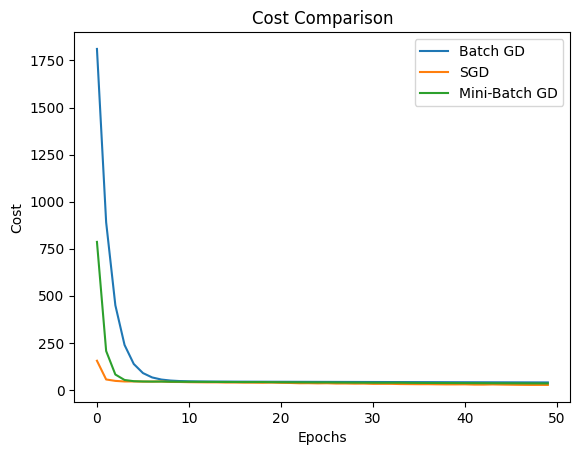

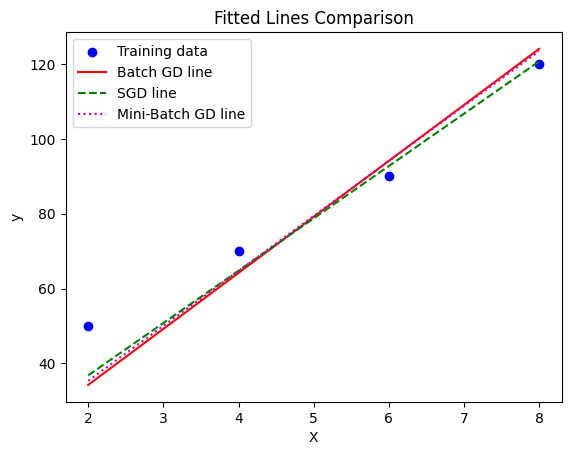

In [12]:
# Plot cost curves
plt.plot(cost_bgd, label="Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.plot(cost_mbgd, label="Mini-Batch GD")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Cost Comparison")
plt.legend()
plt.show()

# Plot fitted lines
x_line = np.linspace(min(X), max(X), 100)
plt.scatter(X, y, color="blue", label="Training data")
plt.plot(x_line, t0_b + t1_b*x_line, "r-", label="Batch GD line")
plt.plot(x_line, t0_s + t1_s*x_line, "g--", label="SGD line")
plt.plot(x_line, t0_m + t1_m*x_line, "m:", label="Mini-Batch GD line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Fitted Lines Comparison")
plt.legend()
plt.show()
